# Step 1. Conversion of GEM Stereo-seq Data

In [ ]:
# TODO: Replace the path to your Gem Stereo-seq data

path = "./C04042E3.tissue.gem.gz"

In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix
import anndata as ad

from typing import Optional

def gem_to_visium_format(
    gem_path: str,
    library_id: str = "gem",
    hires_image: Optional[str] = None,
    lowres_image: Optional[str] = None,
    tissue_hires_scalef: float = 1.0,
    tissue_lowres_scalef: float = 1.0,
    spot_diameter_fullres: float = 100.0,
) -> ad.AnnData:
    """
    Convert a GEM file to a Visium-compatible AnnData object.
    """
    # Load GEM file
    gem = pd.read_csv(gem_path, sep=None, engine="python", compression="infer", comment="#")

    # Generate barcode string
    gem["barcode"] = gem.apply(lambda row: f"s_002um_{int(row['x']):05}_{int(row['y']):05}-1", axis=1)

    # Unique lists
    barcodes = gem["barcode"].unique()
    genes = gem["geneID"].unique()

    barcode_to_idx = {bc: i for i, bc in enumerate(barcodes)}
    gene_to_idx = {g: i for i, g in enumerate(genes)}

    # Build sparse matrix
    row = gem["barcode"].map(barcode_to_idx)
    col = gem["geneID"].map(gene_to_idx)
    data = gem["MIDCount"].astype(int)
    X = coo_matrix((data, (row, col)), shape=(len(barcodes), len(genes)))

    # Create AnnData
    adata = ad.AnnData(X)
    adata.obs_names = barcodes
    adata.var_names = genes

    # Extract row/col from barcode
    coords = pd.DataFrame([bc.split("_")[2:4] for bc in barcodes], columns=["x", "y"])
    coords["x"] = coords["x"].astype(int)
    coords["y"] = coords["y"].str[:-2].astype(int)
    
    adata.obs["array_row"] = coords["y"].values
    adata.obs["array_col"] = coords["x"].values

    adata.obsm["spatial"] = np.stack(
        [adata.obs["array_col"], adata.obs["array_row"]], axis=1
    )
    adata.uns["spatial"] = {
        library_id: {
            "images": {
                "hires": hires_image,
                "lowres": lowres_image,
            },
            "scalefactors": {
                "tissue_hires_scalef": tissue_hires_scalef,
                "tissue_lowres_scalef": tissue_lowres_scalef,
                "spot_diameter_fullres": spot_diameter_fullres,
            },
        }
    }

    return adata

# Convert and Check

This might take aroung ~60 mins for conversion

In [8]:
adata = gem_to_visium_format(path)


print(adata)                      # dims, obs/var counts
print(adata.obs.head())          # should include array_row/array_col
print(adata.obsm["spatial"][:5]) # first 5 spatial coords


AnnData object with n_obs × n_vars = 104429812 × 27441
    obs: 'array_row', 'array_col'
    uns: 'spatial'
    obsm: 'spatial'
                       array_row  array_col
s_002um_03684_07888-1       7888       3684
s_002um_03864_07234-1       7234       3864
s_002um_03987_07889-1       7889       3987
s_002um_04006_07468-1       7468       4006
s_002um_04038_07569-1       7569       4038
[[3684 7888]
 [3864 7234]
 [3987 7889]
 [4006 7468]
 [4038 7569]]


# Save File

In [9]:
adata.X = adata.X.tocsr()

# TODO: Replace the output path where the file will be saved.
adata.write_h5ad("./C04042E3.h5ad") 


# Spatial Alignment Verification

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

# TODO: Replace this path with the path to the H&E TIFF image paired with the Stereo-seq data.
img = plt.imread("./C04042E3_HE_regist.tif")

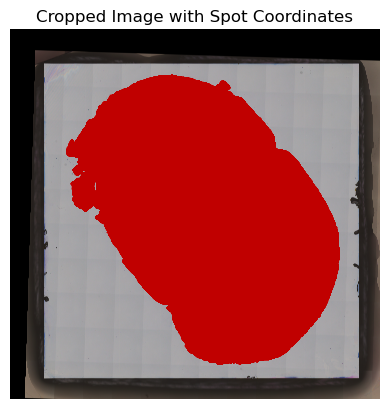

In [13]:

plt.imshow(img)
spatial = adata.obsm["spatial"]
plt.scatter(spatial[:, 0], spatial[:, 1], s=0.05, c="red", alpha = 0.05)
plt.title("Cropped Image with Spot Coordinates")
plt.axis("off")
plt.show()